# WiniCari — 02 Preprocessing: GPS Trip Reconstruction

**Goal:** turn raw GPS pings (`Historique_pos`) into **reconstructed trips with a derived
actual arrival time per stop** — the shared foundation for Delay prediction (labels),
Anomaly detection and GPS Fallback.

**Why derive it:** `service` / `session_ouverte` only log when a driver *opens* a run. The
arrival at the terminus, the turnaround, and the **return trip are never logged** (a driver
typically opens one service for the whole day, `voyages` empty). So trips can only be
recovered from the **GPS track**.

> The production pipeline lives in **`src/data/foundation.py`** and the batch CLI in
> **`src/data/build_foundation.py`**. This notebook *demonstrates and visualizes* that
> library, then loads the persisted dataset — it does not re-implement anything.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.db import get_db
from src.data import foundation as fdn

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

CFG = fdn.Config()          # all tunables in one dataclass
CFG

Config(min_anchors=4, min_pings=300, first_usable_day='d20220601', dedup_round=6, signal_gap_s=600, proj_window=3, proj_gap_reset_s=900, smooth_window=15, reversal_frac=0.15, reversal_floor_m=2000.0, min_span_frac=0.06, min_span_floor_m=1500.0, min_trip_min=8.0, layover_gap_s=2400, park_frac=0.05, full_frac=0.1, arrival_thresh_m=350.0)

## Line geometry — keep geocoded anchors, drop placeholders

`array_lat/lng_opendata` maps one coordinate per stop, but many stops are stored as `0.0`
(not geocoded). We keep the geocoded **anchors** in route order and skip the rest — partial
coverage, not a reason to drop a line. `code` is **not unique across companies**, so we key
everything by `(code, societe)`.

In [2]:
# One query builds {(code, societe) -> anchor stops with cumulative route distance}
USABLE = fdn.build_usable_lines(db_winicari, CFG)

n_zero = sum(len(fdn.real_anchor_stops(lg)) == 0
             for lg in db_winicari["ligne"].find({}, {"array_lat_opendata": 1,
                                                      "array_lng_opendata": 1}))
print(f"usable (code, societe) lines: {len(USABLE)} | lines with 0 geocoded stops: {n_zero}")
USABLE[("209", "S.R.T.K")].head()

usable (code, societe) lines: 135 | lines with 0 geocoded stops: 249


,seq,route_seq,name,lat,lon,s_m
0,0,0,KASSERINE,35.178056,8.847499,0.000000
1,1,1,BOUZGUEM,35.209142,8.894370,5485.235148
2,2,2,EL GARRAA,35.228854,8.960128,11848.232621
3,3,3,CHRAYA,35.255313,9.022020,18192.423815
4,4,4,SBEITLA,35.231061,9.130617,28416.628099


## 1. Load + clean one bus-day

`load_pings` normalizes the schema drift (`localisation.x=lat`, `.y=lon`; speed = top-level
`speed` else `bus.vitesse`). `clean_pings` drops consecutive stationary duplicates (~10%)
and flags signal gaps. We fix one clean intercity example for reproducibility.

In [3]:
LINE, SOCIETE, BUS, DAY = "209", "S.R.T.K", 6030, "d20260615"
stops = USABLE[(LINE, SOCIETE)]

raw = fdn.load_pings(db_gps, DAY, LINE, BUS)
g = fdn.clean_pings(raw, CFG)
print(f"line {LINE} {SOCIETE} bus {BUS} {DAY[1:]} | stops={len(stops)}")
print(f"raw pings {len(raw)} -> cleaned {len(g)} (removed {len(raw)-len(g)} stationary, "
      f"{100*(len(raw)-len(g))//len(raw)}%) | median interval {g['gap_s'].median():.0f}s "
      f"| signal gaps {int(g['signal_gap'].sum())} | largest {g['gap_s'].max():.0f}s")
g.head()

line 209 S.R.T.K bus 6030 20260615 | stops=22
raw pings 4023 -> cleaned 3582 (removed 441 stationary, 10%) | median interval 5s | signal gaps 4 | largest 3607s


,t,lat,lon,speed,gap_s,signal_gap
0,2026-06-15 09:51:43.431,35.177807,8.847803,0.00000,NaN,False
1,2026-06-15 09:53:08.483,35.177807,8.847807,0.00000,85.052,False
2,2026-06-15 09:53:18.483,35.177807,8.847805,0.14816,10.000,False
3,2026-06-15 09:53:58.500,35.177807,8.847807,0.00000,40.017,False
4,2026-06-15 09:54:58.518,35.177807,8.847805,0.00000,60.018,False


## 2. Map-match each ping to a route distance

`project_to_route` does a **sequential (windowed) projection** onto the anchor polyline,
giving a smooth distance-along-route `s` (and off-route `off_m`). The windowing keeps `s`
physically smooth despite sparse anchors — the key to clean segmentation.

route length (anchor polyline): 192 km | mean off-route distance: 336 m


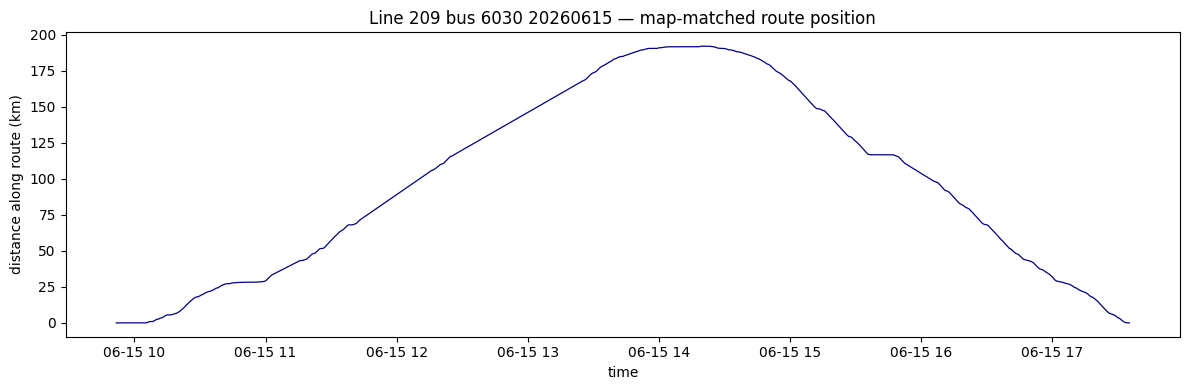

In [4]:
g, route_len = fdn.project_to_route(g, stops, CFG)
print(f"route length (anchor polyline): {route_len/1000:.0f} km | "
      f"mean off-route distance: {g['off_m'].mean():.0f} m")

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.9, color="navy")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} bus {BUS} {DAY[1:]} — map-matched route position")
plt.tight_layout(); plt.show()

## 3. Segment trips — full **and** partial

`segment_trips` detects **direction swings** (turnarounds) using a scale-invariant
hysteresis (fraction of route length), so it works for a 200 km intercity line and a 6 km
urban loop alike. It splits a same-direction run **only** at a *parked* layover gap (big
time gap where the bus barely moved) — so a mid-route signal gap does **not** fragment one
run, and a bus that turns back early is kept as a **partial** trip.

detected 2 trips (2 full, 0 partial)
      dir  full  start    end     km
0   ALLER  True  09:51  14:19  192.0
1  RETOUR  True  14:19  17:35  192.0


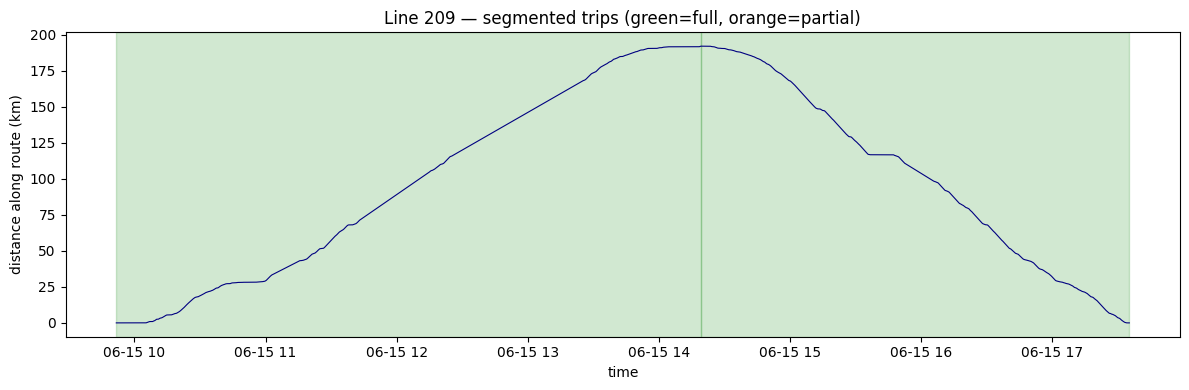

In [5]:
trips = fdn.segment_trips(g, route_len, CFG)
view = trips.assign(start=trips["start"].dt.strftime("%H:%M"),
                    end=trips["end"].dt.strftime("%H:%M"),
                    km=((trips["s_hi"] - trips["s_lo"]) / 1000).round(1))[
    ["dir", "full", "start", "end", "km"]]
print(f"detected {len(trips)} trips ({trips['full'].sum()} full, {(~trips['full']).sum()} partial)")
print(view.to_string())

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.8, color="navy")
for _, tr in trips.iterrows():
    plt.axvspan(tr["start"], tr["end"], alpha=0.18,
                color="green" if tr["full"] else "orange")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} — segmented trips (green=full, orange=partial)")
plt.tight_layout(); plt.show()

## 4. Derive actual arrival time per stop

For each trip, `derive_arrivals` snaps the stops within the trip's covered range to pings
**in travel order**, enforcing monotonically increasing arrival times. Match rate is itself
a per-line data-quality signal.

In [6]:
tr = trips.iloc[0]
arr = fdn.derive_arrivals(g, tr, stops, CFG)
print(f"Trip 0 ({tr['dir']}, full={tr['full']}): matched {arr['matched'].sum()}/{len(arr)} "
      f"covered stops ({arr['matched'].mean():.0%})")
arr.assign(arrival=arr["arrival"].dt.strftime("%H:%M:%S"))

Trip 0 (ALLER, full=True): matched 13/22 covered stops (59%)


,seq,route_seq,stop,arrival,dist_m,matched
0,0,0,KASSERINE,09:55:18,39,True
1,1,1,BOUZGUEM,10:14:53,6,True
2,2,2,EL GARRAA,10:23:27,136,True
3,3,3,CHRAYA,10:29:17,20,True
4,4,4,SBEITLA,10:57:40,113,True
5,5,5,OUED ELMIOU,NaN,2927,False
6,6,6,ESSABALA,11:16:22,38,True
7,7,7,EL BLAKAT,11:24:52,35,True
8,8,8,M'AMMER,11:31:17,12,True
9,9,9,BLAK BOUZID,11:40:09,1,True


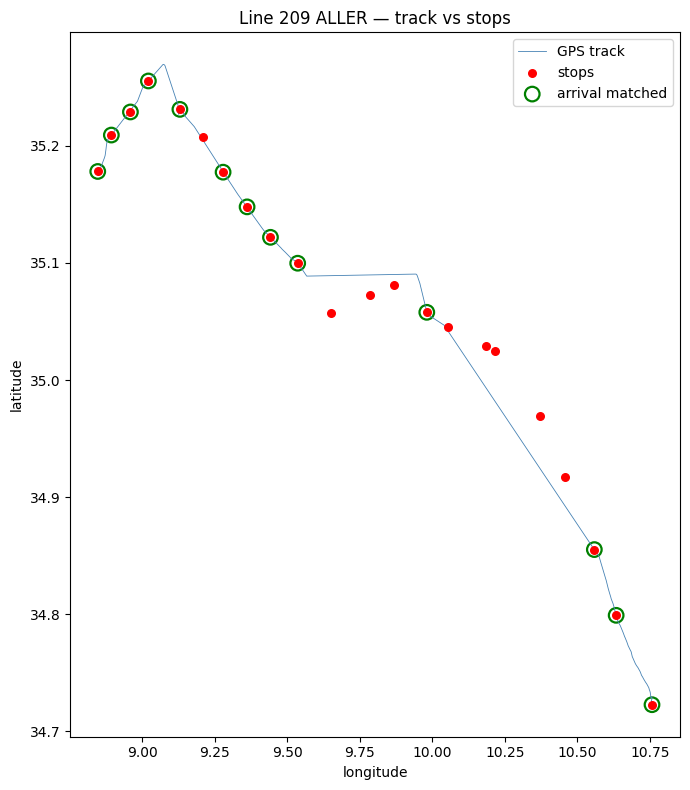

In [7]:
# Map view: route stops + the bus track + matched arrivals for trip 0
seg = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])]
matched = arr[arr["matched"]]
plt.figure(figsize=(7, 8))
plt.plot(seg["lon"], seg["lat"], linewidth=0.6, color="steelblue", label="GPS track")
plt.scatter(stops["lon"], stops["lat"], c="red", s=30, zorder=3, label="stops")
plt.scatter([stops["lon"].iloc[s] for s in matched["seq"]],
            [stops["lat"].iloc[s] for s in matched["seq"]],
            facecolors="none", edgecolors="green", s=110, linewidths=1.6, label="arrival matched")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title(f"Line {LINE} {tr['dir']} — track vs stops"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Full pipeline for one bus-day

`reconstruct_bus_day` chains all of the above and returns one row per covered stop-arrival.

In [8]:
demo = fdn.reconstruct_bus_day(db_gps, DAY, LINE, SOCIETE, BUS, stops, CFG)
print(f"rows={len(demo)} | trips={demo['trip_id'].nunique()} | "
      f"match rate={100*demo['matched'].mean():.0f}%")
print("columns:", list(demo.columns))
demo.head(12)

rows=44 | trips=2 | match rate=75%
columns: ['day', 'line', 'societe', 'bus', 'trip_id', 'dir', 'full', 'trip_start', 'trip_end', 'seq', 'route_seq', 'stop', 'arrival', 'dist_m', 'matched']


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,dist_m,matched
0,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,0,0,KASSERINE,2026-06-15 09:55:18.519,39,True
1,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,1,1,BOUZGUEM,2026-06-15 10:14:53.457,6,True
2,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,2,2,EL GARRAA,2026-06-15 10:23:27.524,136,True
3,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,3,3,CHRAYA,2026-06-15 10:29:17.632,20,True
4,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,4,4,SBEITLA,2026-06-15 10:57:40.230,113,True
5,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,5,5,OUED ELMIOU,NaT,2927,False
6,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,6,6,ESSABALA,2026-06-15 11:16:22.479,38,True
7,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,7,7,EL BLAKAT,2026-06-15 11:24:52.626,35,True
8,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,8,8,M'AMMER,2026-06-15 11:31:17.734,12,True
9,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,9,9,BLAK BOUZID,2026-06-15 11:40:09.397,1,True


## 6. Batch + persist (production)

The dataset is built by the resumable CLI, which loops every usable `(day, line, societe,
bus)` and writes monthly parquet shards, then combines them:

```bash
python -m src.data.build_foundation                 # full usable range (>= 2022-06, ~40 min)
python -m src.data.build_foundation --since 202501  # only months >= 2025-01
```

Below we **load** the persisted dataset and analyze it — no heavy compute in the notebook.

In [9]:
# repo root resolved from the library location -> works regardless of cwd
OUT = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"
if OUT.exists():
    fa = pd.read_parquet(OUT)
    bd = fa.groupby(["day", "line", "societe", "bus"]).ngroups
    tr_n = fa.groupby(["day", "line", "societe", "bus", "trip_id"]).ngroups
    print(f"loaded {OUT.name}: rows={len(fa)} | bus-days={bd} | trips={tr_n} "
          f"| lines={fa['line'].nunique()} | overall match={100*fa['matched'].mean():.0f}%")
    print(f"day range: {fa['day'].min()} .. {fa['day'].max()} | "
          f"full trips={fa.groupby(['day','line','bus','trip_id'])['full'].first().sum()}")
else:
    fa = pd.DataFrame()
    print(f"{OUT} not found — run the CLI above to build it.")
fa.head()

loaded foundation_arrivals_full.parquet: rows=2908 | bus-days=69 | trips=349 | lines=8 | overall match=70%
day range: 20260601 .. 20260621 | full trips=266


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,dist_m,matched
0,20260601,3,TCV,182,0,ALLER,False,2026-06-01 05:49:18.347,2026-06-01 06:18:42.514,1,1,stop1,2026-06-01 06:01:32.552,14,True
1,20260601,3,TCV,182,0,ALLER,False,2026-06-01 05:49:18.347,2026-06-01 06:18:42.514,2,2,stop2,2026-06-01 06:05:21.526,30,True
2,20260601,3,TCV,182,0,ALLER,False,2026-06-01 05:49:18.347,2026-06-01 06:18:42.514,3,3,stop3,2026-06-01 06:06:31.554,10,True
3,20260601,3,TCV,182,0,ALLER,False,2026-06-01 05:49:18.347,2026-06-01 06:18:42.514,4,4,stop4,2026-06-01 06:07:56.588,10,True
4,20260601,3,TCV,182,0,ALLER,False,2026-06-01 05:49:18.347,2026-06-01 06:18:42.514,5,5,stop5,2026-06-01 06:17:17.485,51,True


bus_days  trips  stops  match_rate
societe line                                    
S.R.T.K 215          1      5      5       100.0
S.T.S   306          1     54     54        93.0
S.R.T.K 209          4    176    176        87.0
TCV     3           15   1539   1539        84.0
S.R.T.K 217         10    335    335        68.0
        203         10    352    352        41.0
        216          1     17     17        41.0
        212         12    430    430        37.0

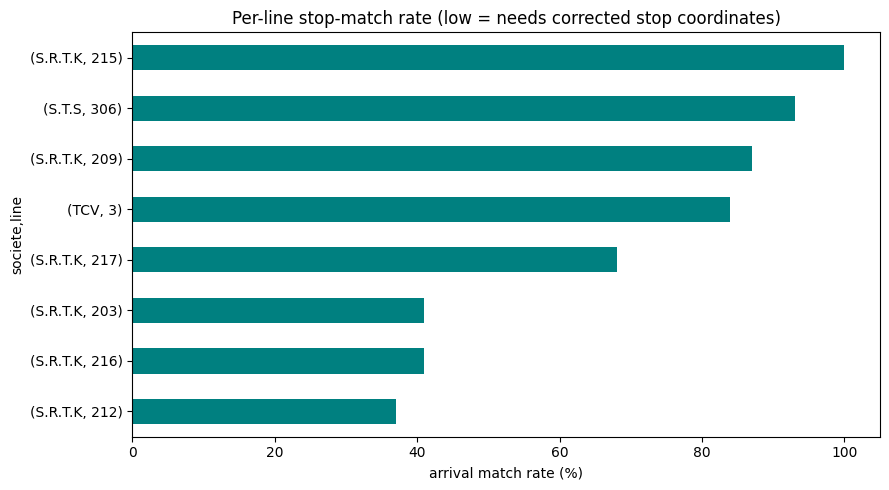

In [10]:
# Per-line match rate = headline data-quality signal (which lines have good stop coords)
if len(fa):
    per_line = (fa.groupby(["societe", "line"])
                  .agg(bus_days=("day", "nunique"), trips=("trip_id", "size"),
                       stops=("matched", "size"), match_rate=("matched", "mean"))
                  .assign(match_rate=lambda d: (100 * d["match_rate"]).round())
                  .sort_values("match_rate", ascending=False))
    display(per_line)

    ax = per_line["match_rate"].plot(kind="barh", figsize=(9, 5), color="teal")
    ax.set_xlabel("arrival match rate (%)")
    ax.set_title("Per-line stop-match rate (low = needs corrected stop coordinates)")
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

### Caveats / quality notes (feed back to the audit)

- **Geometry is partial:** ~135 lines usable (>= 4 geocoded anchors); ~249 have none. Sparse
  anchors mean the polyline only approximates the road — segmentation uses distance *swings*
  with hysteresis rather than exact map-matching for robustness.
- **Match rate per line is the quality metric.** Well-mapped intercity lines score high; short
  urban lines and lines with imprecise stop coords (e.g. some S.R.T.K lines) score low and
  should get corrected coordinates from the company before they're model-ready.
- **Partial trips are kept** (bus turns back early, or day ends mid-run) and flagged via
  `full=False`; mid-route signal gaps do not fragment a run.
- **No scheduled per-stop times exist yet** to subtract — `ligne.horaires` only holds
  departure times. Delay labelling (actual − scheduled) is the next notebook once schedules
  are mapped per stop.
- All tunables live in `fdn.Config`; the same code path runs in the notebook and the CLI.